In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data.csv")

#**1.Display dataset information and check missing values.**

In [ ]:
print(df.info())
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76310 entries, 0 to 76309
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   employer_name               76310 non-null  object 
 1   city                        76301 non-null  object 
 2   state                       76310 non-null  object 
 3   zip                         76298 non-null  float64
 4   naics_code                  62087 non-null  float64
 5   naics_description           57583 non-null  object 
 6   parent_name                 28120 non-null  object 
 7   agencies_with_violations    76310 non-null  int64  
 8   osha_violations             76310 non-null  int64  
 9   osha_penalties              76310 non-null  int64  
 10  osha_fatalities             76310 non-null  int64  
 11  whd_cases                   76310 non-null  int64  
 12  whd_backwages               76310 non-null  float64
 13  msha_violations             763

,0
employer_name,0
city,9
state,0
zip,12
naics_code,14223
naics_description,18727
parent_name,48190
agencies_with_violations,0
osha_violations,0
osha_penalties,0


#**2.Remove duplicate rows.**

In [ ]:
df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (76310, 20)


#**3.Fill missing numerical values with median.**

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df.isnull().sum()

,0
employer_name,0
city,9
state,0
zip,0
naics_code,0
naics_description,18727
parent_name,48190
agencies_with_violations,0
osha_violations,0
osha_penalties,0


#**4.Check data types and convert if necessary.**

In [ ]:
df.dtypes

,0
employer_name,object
city,object
state,object
zip,float64
naics_code,float64
naics_description,object
parent_name,object
agencies_with_violations,int64
osha_violations,int64
osha_penalties,int64


# **5. Find the Top 10 Companies with Highest Risk Score**

In [ ]:
import pandas as pd
df = pd.read_csv('data.csv')
top10_risk = df.nlargest(10, 'risk_score')[['employer_name', 'risk_score']]
print(top10_risk)

                                 employer_name  risk_score
4                   BRADFORD WHITE CORPORATION       100.0
7                     FUYAO GLASS AMERICA INC.       100.0
8                           OVERHILL FARMS INC       100.0
10                     SPIRIT AEROSYSTEMS, INC       100.0
12                          NEBRASKA BEEF, LTD       100.0
19                        IGLOO PRODUCTS CORP.       100.0
24           68957 - UNITED PARCEL SERVICE INC       100.0
74                         HOSTESS BRANDS, LLC       100.0
285                             REPUBLIC STEEL       100.0
293  YOKOHAMA TIRE MANUFACTURING VIRGINIA, LLC       100.0


#**6. Count Companies by State**

In [ ]:
state_count = df['state'].value_counts()
state_count

,count
state,
CA,11367
MI,4760
NY,4572
TX,4389
PA,4206
IL,3421
OH,3150
NJ,2284
WA,2037


#**7. Average Risk Score by State**

In [ ]:
avg_risk = df.groupby('state')['risk_score'].mean().sort_values(ascending=False)
print(avg_risk)

state
AS    32.852222
GU    18.629518
VI    15.082439
MP    13.963091
SD    12.262882
DE    12.006270
AK    11.623002
NE    11.258670
AL    10.918610
TN    10.879782
AR    10.166885
NH     9.675366
GA     9.556010
OH     9.423292
KS     9.280352
ID     9.239483
KY     9.175802
NJ     9.116668
RI     8.883645
WI     8.818078
IA     8.737973
MS     8.680102
HI     8.615996
OK     8.430937
CT     8.376944
MI     8.325271
MA     8.154542
VT     8.105299
ME     8.100528
OR     8.087098
IL     7.820775
IN     7.700768
NC     7.352331
MO     7.321226
VA     7.319728
MD     7.191462
WV     7.191027
UT     7.162261
PA     7.140511
SC     7.014844
PR     6.882657
MN     6.802097
WY     6.726640
ND     6.576603
NY     6.523104
FL     6.493572
LA     6.378033
NV     6.298424
NM     6.100627
MT     6.023701
TX     5.896922
CO     5.654924
CA     5.297932
DC     5.275000
WA     4.250074
AZ     2.979078
Name: risk_score, dtype: float64


#**8. Find average, maximum and minimum OSHA Penalties.**

In [ ]:
print("Average =",np.mean(df['osha_penalties']))
print("Maximum =",np.max(df['osha_penalties']))
print("Minimum =",np.min(df['osha_penalties']))

Average = 8456.121412658891
Maximum = 38097000
Minimum = 0


#**9.Create a new column Total Penalties.**

In [ ]:
df['total_penalties'] = (
    df['osha_penalties']
    + df['msha_penalties']
    + df['epa_penalties']
)

df[['employer_name','total_penalties']].head()

,employer_name,total_penalties
0,BRENNTAG PACIFIC INC.,10147.0
1,"MOSAIC FERTILIZER, LLC",1258641.0
2,"ALUMINUM SHAPES, LLC.",814102.0
3,"REMINGTON ARMS COMPANY, LLC",244471.0
4,BRADFORD WHITE CORPORATION,268620.0


#**10. Histogram of Risk Scores**

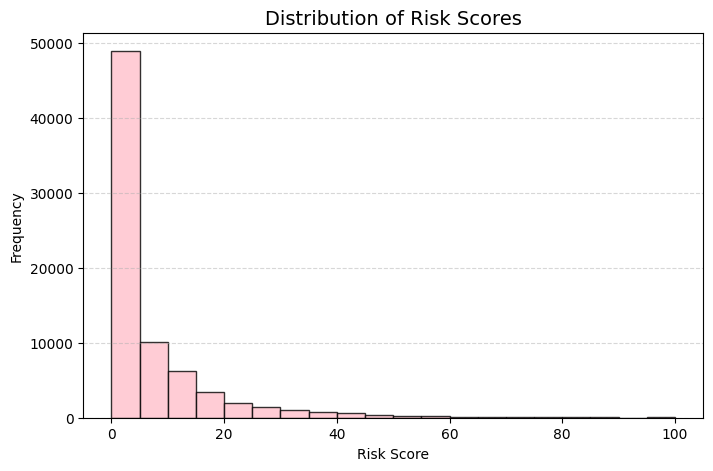

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['risk_score'],
         bins=20,
         color='pink',
         edgecolor='black',
         alpha=0.8)

plt.title('Distribution of Risk Scores', fontsize=14)
plt.xlabel('Risk Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# **11. Top 10 States by Average Risk Score (Bar Chart)**

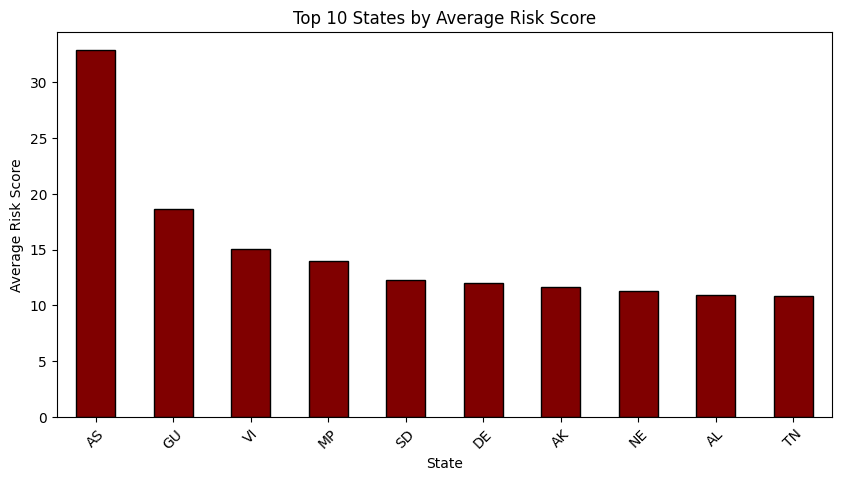

In [ ]:
top_states = df.groupby('state')['risk_score'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind='bar',
                color='maroon',
                edgecolor='black')

plt.title('Top 10 States by Average Risk Score')
plt.xlabel('State')
plt.ylabel('Average Risk Score')
plt.xticks(rotation=45)

plt.show()

#**12. Scatter Plot between OSHA Violations and OSHA Penalties.**

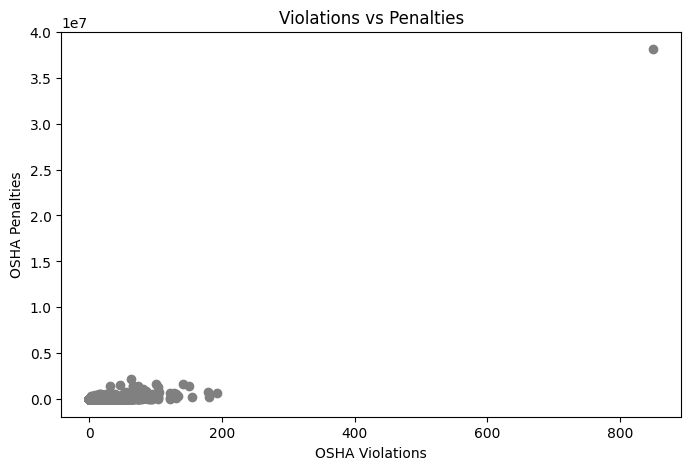

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['osha_violations'],
            df['osha_penalties'],
            color='gray')
plt.xlabel("OSHA Violations")
plt.ylabel("OSHA Penalties")
plt.title("Violations vs Penalties")
plt.show()

#**13. Line Chart of Average Risk Score by State.**

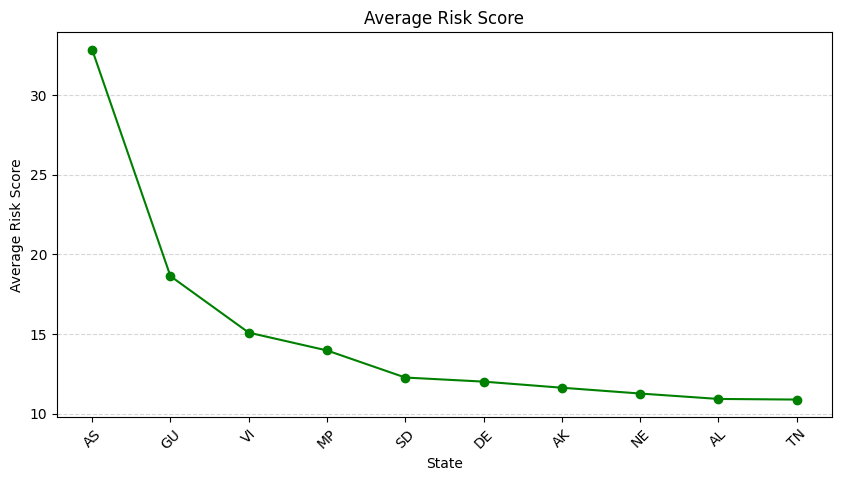

In [ ]:
risk = df.groupby('state')['risk_score'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.plot(risk.index,
         risk.values,
         marker='o',
         color='green')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xlabel('State')
plt.ylabel('Average Risk Score')
plt.xticks(rotation=45)
plt.title("Average Risk Score")
plt.show()

#**14. Correlation Heatmap.**

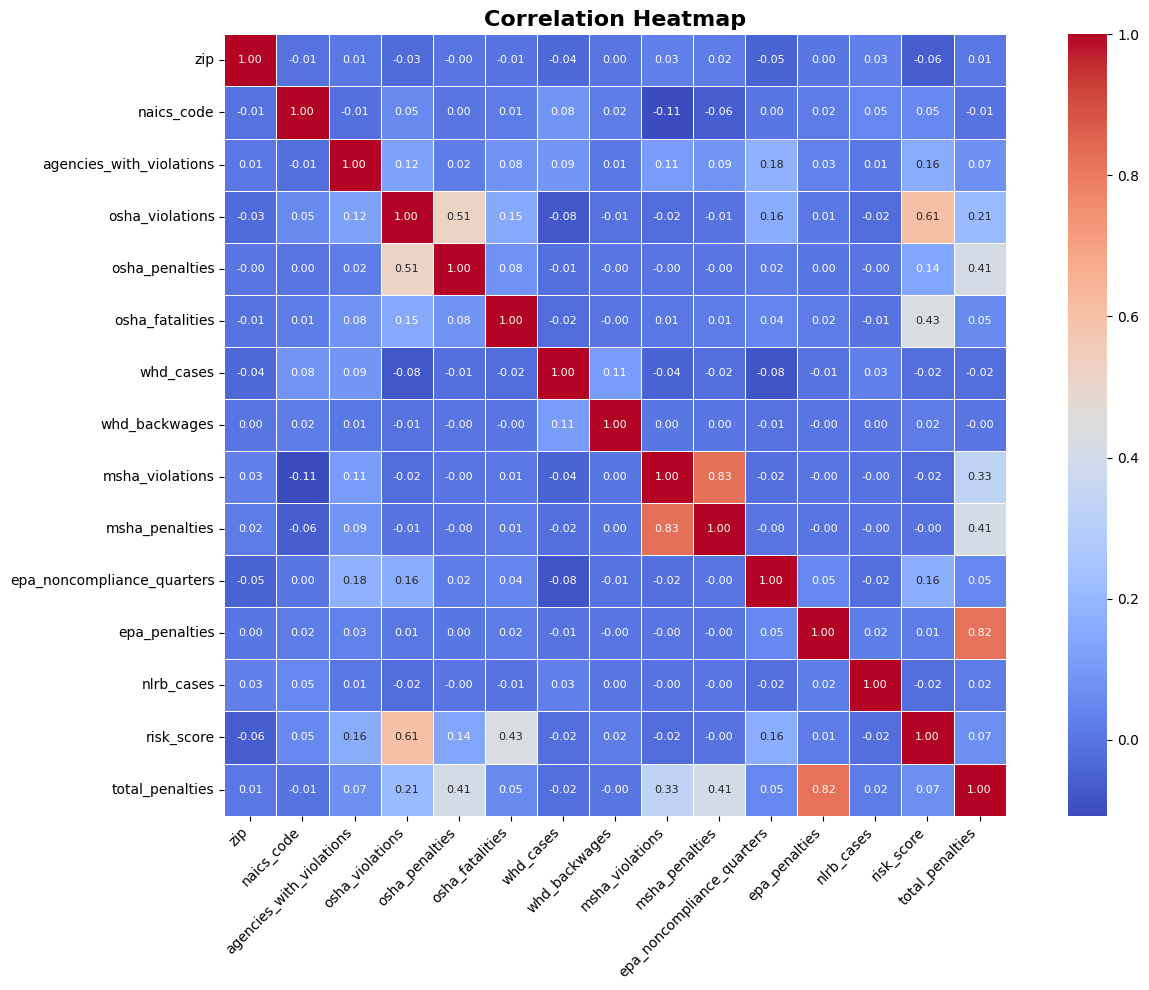

In [ ]:
plt.figure(figsize=(14,10))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            linewidths=0.5,
            square=True,
            cbar=True,
            annot_kws={"size":8})
plt.title("Correlation Heatmap", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#**15. Boxplot of Risk Score by Debarred Status.**

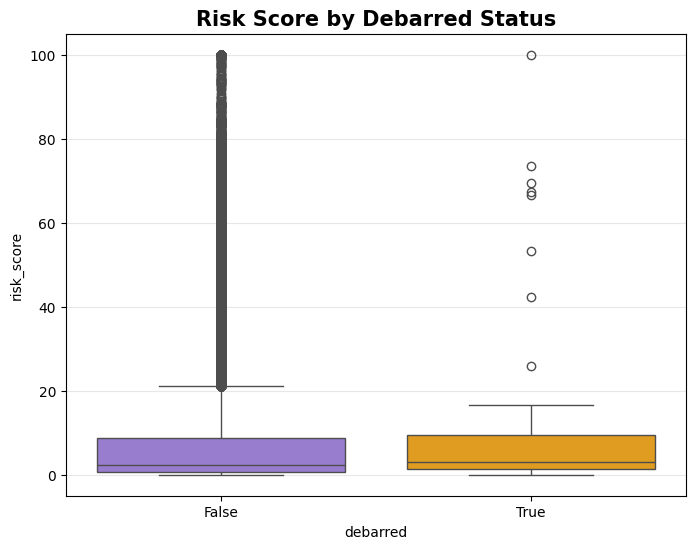

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(
    x='debarred',
    y='risk_score',
    hue='debarred',
    data=df,
    palette=['mediumpurple', 'orange'],
    legend=False
)
plt.title("Risk Score by Debarred Status", fontsize=15, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()

#**16. Countplot of Companies by State (Top 10).**

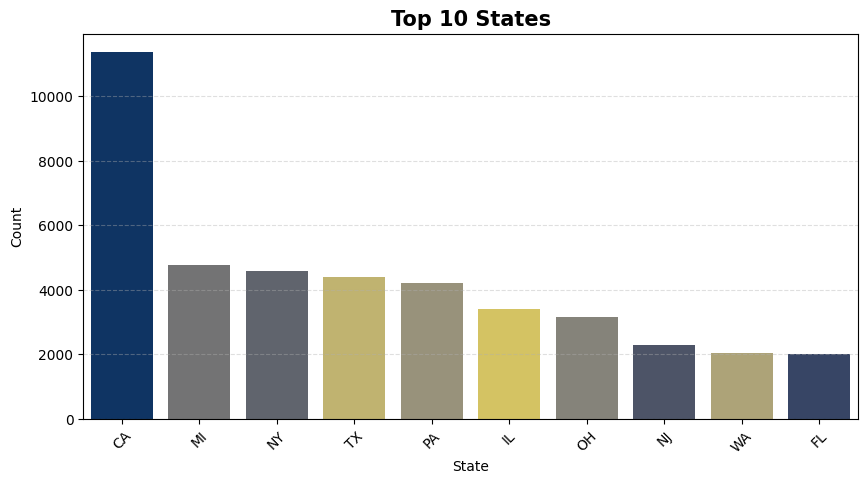

In [ ]:
top = df['state'].value_counts().head(10).index
plt.figure(figsize=(10,5))
sns.countplot(
    data=df[df['state'].isin(top)],
    x='state',
    order=top,
    hue='state',
    palette='cividis',
    legend=False
)
plt.xticks(rotation=45)
plt.title("Top 10 States", fontsize=15, fontweight='bold')
plt.xlabel("State")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

#**17.Analyze the relationship between Risk Score, OSHA Penalties, OSHA Violations, and EPA Penalties using a Seaborn Pairplot. Identify any patterns or correlations among these variables.**

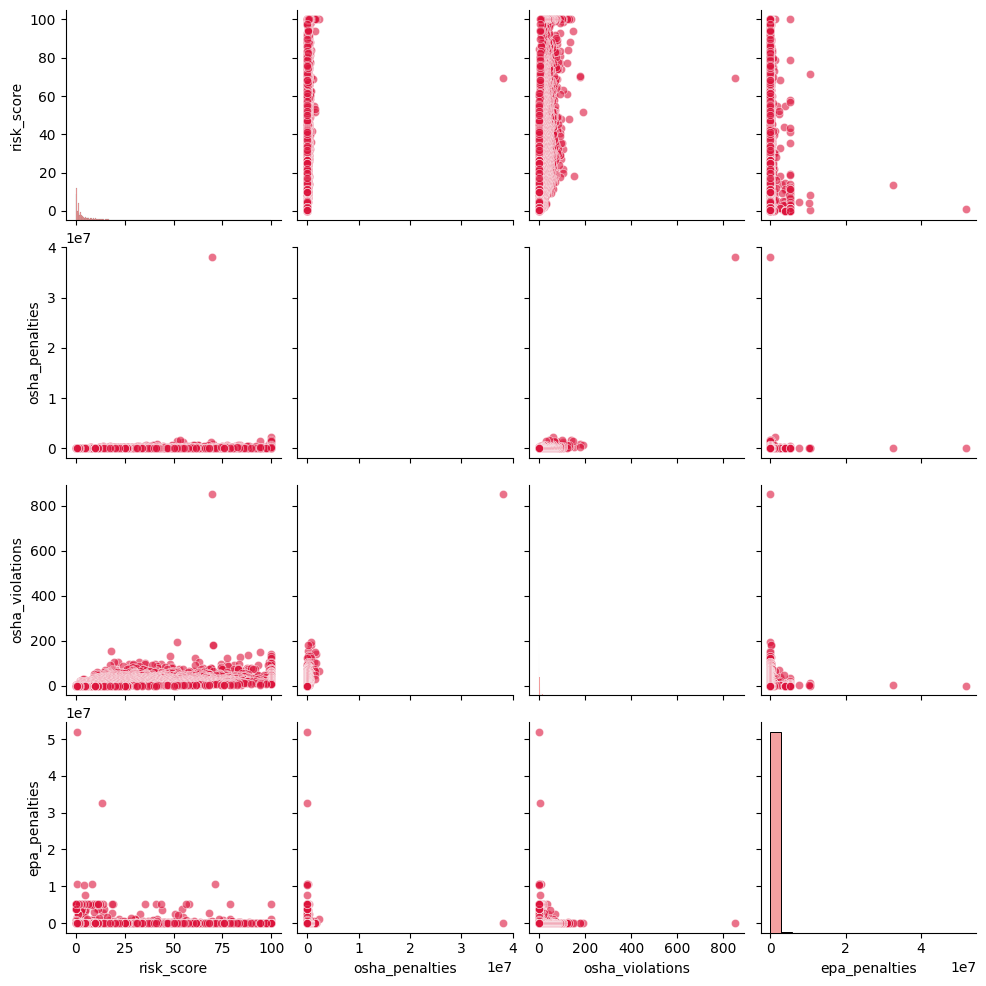

In [59]:
sns.pairplot(
    df[['risk_score',
        'osha_penalties',
        'osha_violations',
        'epa_penalties']],
    plot_kws={
        'color': 'crimson',
        'alpha': 0.6,
        's': 35
    },
    diag_kws={
        'color': 'lightcoral'
    }
)
plt.show()

#**18. Examine the relationship between OSHA Penalties and Risk Score using a Seaborn Regression Plot. Determine whether an increase in OSHA penalties is associated with higher risk scores.**

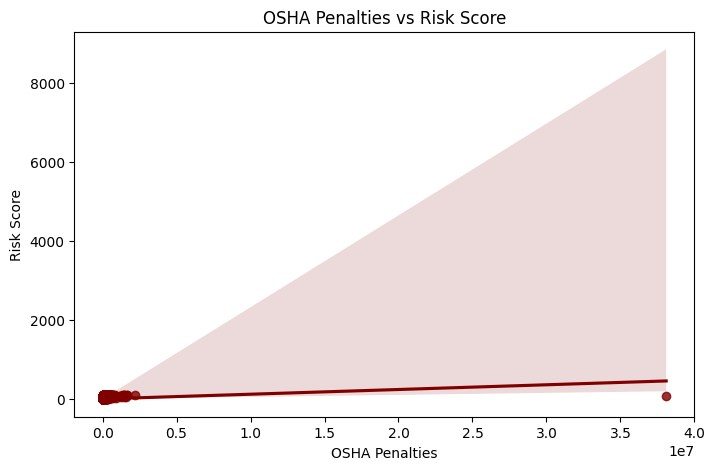

In [60]:
plt.figure(figsize=(8,5))
sns.regplot(x='osha_penalties',
            y='risk_score',
            data=df,
            color='maroon')
plt.title("OSHA Penalties vs Risk Score")
plt.xlabel("OSHA Penalties")
plt.ylabel("Risk Score")
plt.show()